In [62]:
#Do a time series Analysis on icecream sales dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import math

df = pd.read_csv('ice_cream.csv')
df.set_index('date',inplace=True)
print(df.head())



               sale
date               
1972-01-01  59.9622
1972-02-01  67.0605
1972-03-01  74.2350
1972-04-01  78.1120
1972-05-01  84.7636


In [64]:
#Copy the apssengers column inti a new df for more analysis
# df['yearMonth'] = df['date'].dt.year
saleD = df[['sale']].copy(deep=True)
print(saleD)

                sale
date                
1972-01-01   59.9622
1972-02-01   67.0605
1972-03-01   74.2350
1972-04-01   78.1120
1972-05-01   84.7636
...              ...
2019-09-01  100.1741
2019-10-01   90.1684
2019-11-01   79.7223
2019-12-01   75.7094
2020-01-01   83.6290

[577 rows x 1 columns]


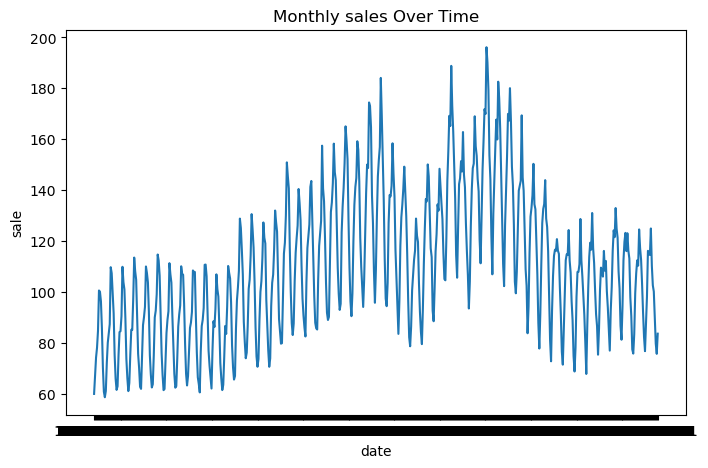

In [66]:
#Visualize initial Data 
plt.figure(figsize=(8,5))
sns.lineplot(x=saleD.index,y=saleD['sale'])
plt.title("Monthly sales Over Time")
plt.show()

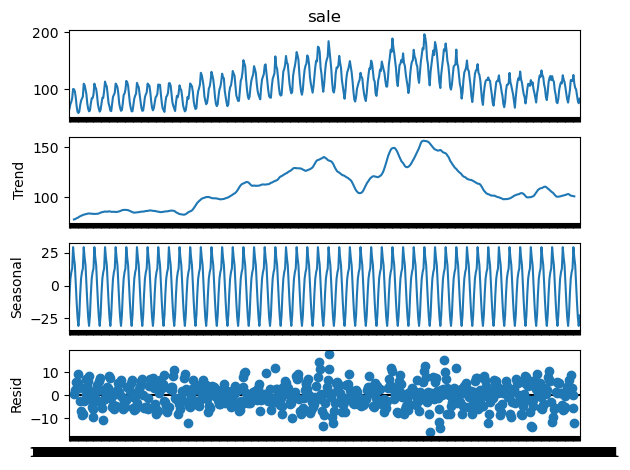

In [67]:
#Decompose to Check TRend and Seasonality
decomposition = seasonal_decompose(saleD.sale,period=12)
decomposition.plot()
plt.show()

In [70]:
#Stationary Check 
def test_stationary(dataFrame,var,window=12):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=window).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=window).std()
    adf_result = adfuller(dataFrame[var])
    p_value = adf_result[1]
    
    print(f"ADF p-value : {p_value:4f}")
    if p_value < 0.05: 
        print("The time series is ststionary (reject H0)")
    else:
        print("Failed to reject  ! The time series is not stationary ")
    
    plt.figure(figsize=(10,5))
    sns.lineplot(x=dataFrame.index,y=dataFrame[var],label='Original')
    sns.lineplot(x=dataFrame.index,y=dataFrame['rollMean'],label='Roll Mean')
    sns.lineplot(x=dataFrame.index,y=dataFrame['rollStd'],label='Roll STD')
    plt.title("Rolling Statistics")
    plt.legend()
    plt.show()


ADF p-value : 0.401499
Failed to reject  ! The time series is not stationary 


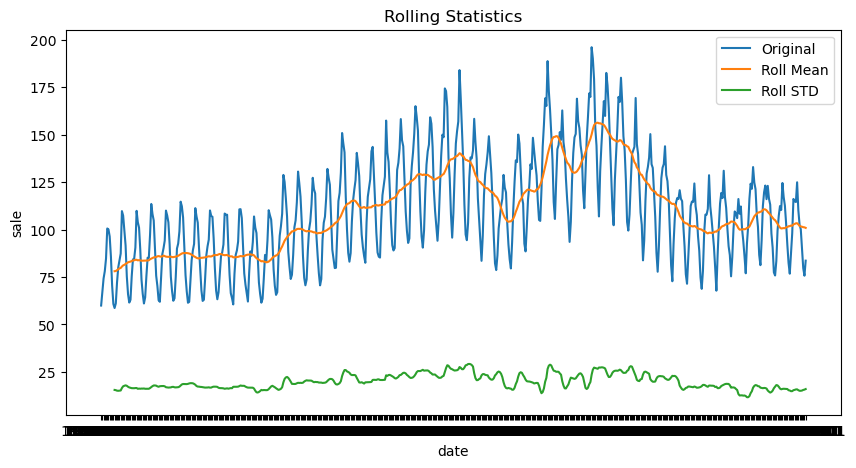

In [71]:
#Test Stationarity
test_stationary(saleD,'sale')

                sale   rollMean    rollStd     shift  shiftDiff
date                                                           
1972-01-01   59.9622        NaN        NaN       NaN        NaN
1972-02-01   67.0605        NaN        NaN   59.9622     7.0983
1972-03-01   74.2350        NaN        NaN   67.0605     7.1745
1972-04-01   78.1120        NaN        NaN   74.2350     3.8770
1972-05-01   84.7636        NaN        NaN   78.1120     6.6516
1972-06-01  100.5960        NaN        NaN   84.7636    15.8324
1972-07-01  100.1263        NaN        NaN  100.5960    -0.4697
1972-08-01   96.3607        NaN        NaN  100.1263    -3.7656
1972-09-01   85.8007        NaN        NaN   96.3607   -10.5600
1972-10-01   70.3934        NaN        NaN   85.8007   -15.4073
1972-11-01   60.8072        NaN        NaN   70.3934    -9.5862
1972-12-01   58.6598  78.073117  15.464092   60.8072    -2.1474
1973-01-01   61.0996  78.167900  15.346029   58.6598     2.4398
1973-02-01   72.2062  78.596708  15.0769

C:\Users\pgcp-bda\AppData\Local\Temp\ipykernel_25884\2333076326.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean'] = dataFrame[var].rolling(window=window).mean()
C:\Users\pgcp-bda\AppData\Local\Temp\ipykernel_25884\2333076326.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd'] = dataFrame[var].rolling(window=window).std()


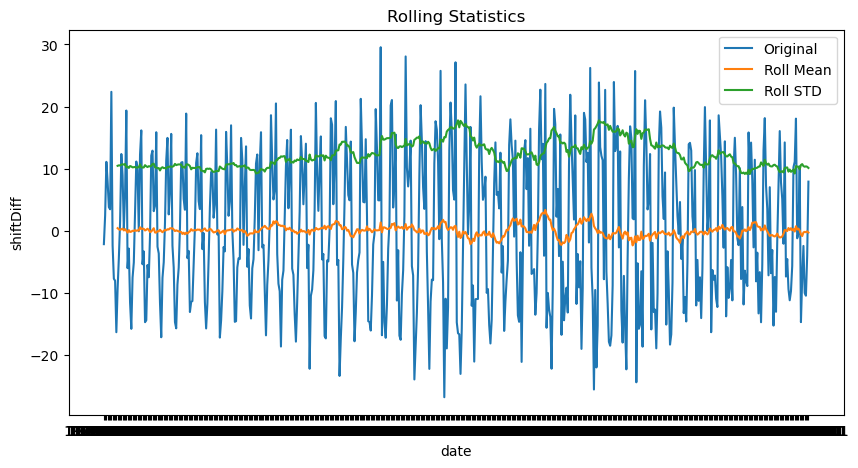

In [72]:
saleD['shift'] = saleD.sale.shift(1)
saleD['shiftDiff'] = saleD['sale'] - saleD['shift']
print(saleD.head(20))
test_stationary(saleD.dropna(),'shiftDiff')

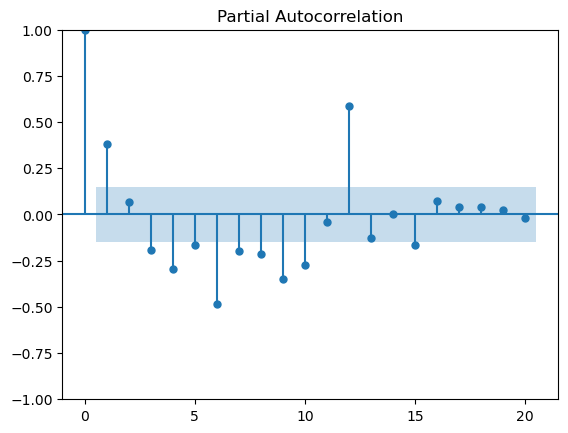

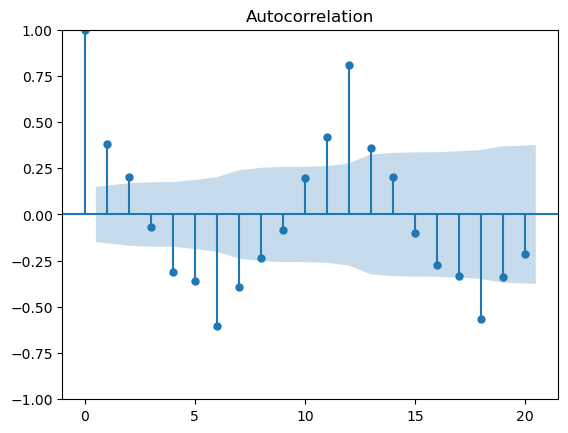

In [82]:
#For ACF - Differnecing of 2 and 12
saleD['secondDiff'] = saleD['sale'].diff(1)
saleD['Diff12'] = saleD['sale'].diff(12)

#PACF and ACF plots
plot_pacf(saleD['secondDiff'].dropna(),lags=20)
plt.show()

plot_acf(saleD['secondDiff'].dropna(),lags=20)
plt.show()

C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                sale    rollMean    rollStd     shift  shiftDiff  secondDiff  \
date                                                                           
2019-09-01  100.1741  101.678975  15.021611  110.2632   -10.0891     -2.4344   
2019-10-01   90.1684  101.515333  15.145254  102.6085   -12.4401    -10.0057   
2019-11-01   79.7223  101.289300  15.472611  100.1741   -20.4518    -10.4461   
2019-12-01   75.7094  101.201683  15.626348   90.1684   -14.4590     -4.0129   
2020-01-01   83.6290  100.920867  15.932076   79.7223     3.9067      7.9196   

            Diff12   arimaPred  diff_combined  sarimaxPred  
date                                                        
2019-09-01 -3.1377  101.994430         3.8206   925.334802  
2019-10-01 -1.9637   96.278871         8.1057   926.932255  
2019-11-01 -2.7124   91.763054         0.4253   911.923602  
2019-12-01 -1.0514   89.686283         0.9123   901.897657  
2020-01-01 -3.3698   90.910151        -0.6574   929.001228  


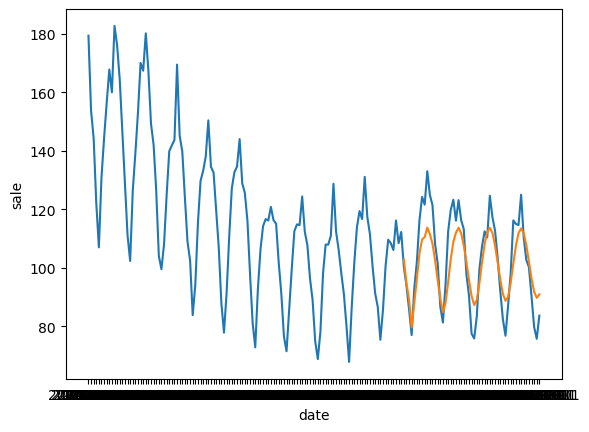

Through the graph we declare the arima predictions are poor


In [85]:
#Test-Train Split

train_size = int(len(saleD) * 0.7)
train = saleD.iloc[:train_size]
test = saleD.iloc[train_size:]

#ARIMA Model
model_arima = ARIMA(train['sale'],order=(12,0,0))
model_arima_fit = model_arima.fit()
arima_pred = model_arima_fit.predict(start=len(train),end = len(saleD)-1)

#Add ARIMA prediction to dataFrame
saleD['arimaPred'] = np.nan
saleD.iloc[train_size:,saleD.columns.get_loc('arimaPred')] = arima_pred.values
print(saleD.tail())

#Plot
sns.lineplot(data=saleD,x=saleD.index,y='sale')
sns.lineplot(data=saleD,x=saleD.index,y='arimaPred')

plt.show()

print("Through the graph we declare the arima predictions are poor")

In [86]:
# saleD['diff_combined'] = saleD['sale'].diff(2).diff(12)

# plot_pacf(saleD['diff_combined'].dropna(),lags=50)
# plt.title("PACF-Seasonal Differencing")
# plt.show()

# plot_acf(saleD['diff_combined'].dropna(),lags=50)
# plt.title("ACF - Seasonal Differencing ")
# plt.show()

In [88]:
model_sarimax = SARIMAX(train['sale'],order=(11,0,0),seasonal_order=(1,0,0,12))
model_sarimax_fit = model_sarimax.fit()
sarimax_pred = model_sarimax_fit.predict(start=len(train),end=len(saleD)-1)


C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [78]:
#Add SARIMAX prediction to DataFrame 
saleD['sarimaxPred'] = np.nan
saleD.iloc[train_size:,saleD.columns.get_loc('sarimaxPred')] = sarimax_pred.values
print(saleD.tail())

                sale    rollMean    rollStd     shift  shiftDiff  secondDiff  \
date                                                                           
2019-09-01  100.1741  101.678975  15.021611  110.2632   -10.0891    -10.0891   
2019-10-01   90.1684  101.515333  15.145254  102.6085   -12.4401    -12.4401   
2019-11-01   79.7223  101.289300  15.472611  100.1741   -20.4518    -20.4518   
2019-12-01   75.7094  101.201683  15.626348   90.1684   -14.4590    -14.4590   
2020-01-01   83.6290  100.920867  15.932076   79.7223     3.9067      3.9067   

            Diff12   arimaPred  diff_combined  sarimaxPred  
date                                                        
2019-09-01 -3.1377  239.138613         3.8206   925.334802  
2019-10-01 -1.9637  239.464166         8.1057   926.932255  
2019-11-01 -2.7124  239.789718         0.4253   911.923602  
2019-12-01 -1.0514  240.115271         0.9123   901.897657  
2020-01-01 -3.3698  240.440824        -0.6574   929.001228  


                sale    rollMean    rollStd     shift  shiftDiff  secondDiff  \
date                                                                           
2005-08-01  179.2849  155.082583  27.239364  196.1737   -16.8888    -16.8888   
2005-09-01  153.7389  155.858592  27.040115  190.2501   -36.5112    -36.5112   
2005-10-01  144.2127  156.249167  26.815670  179.2849   -35.0722    -35.0722   
2005-11-01  122.2164  156.390575  26.613841  153.7389   -31.5225    -31.5225   
2005-12-01  106.9509  156.029642  27.301691  144.2127   -37.2618    -37.2618   

             Diff12   arimaPred  diff_combined  sarimaxPred  
date                                                         
2005-08-01  25.7594  187.400342        -1.3781   184.493238  
2005-09-01   9.3121  186.112459       -23.6737   173.606184  
2005-10-01   4.6869  185.618196       -21.0725   166.611150  
2005-11-01   1.6969  185.527184        -7.6152   152.022177  
2005-12-01  -4.3312  185.641073        -9.0181   140.941295  


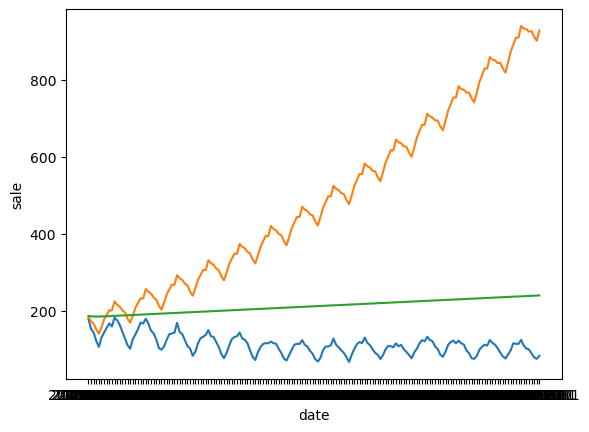

In [79]:
#PLot 
saleD = saleD.dropna()
print(saleD.head())
sns.lineplot(data=saleD,x=saleD.index,y='sale')
sns.lineplot(data=saleD,x=saleD.index,y='sarimaxPred')
sns.lineplot(data=saleD,x=saleD.index,y='arimaPred')
plt.show()

2005-01-01     126.030704
2005-02-01     149.921213
2005-03-01     157.932051
2005-04-01     166.712495
2005-05-01     169.891180
                 ...     
2020-08-01    1018.276873
2020-09-01    1011.844905
2020-10-01    1014.084817
2020-11-01     999.229992
2020-12-01     989.325211
Freq: MS, Name: predicted_mean, Length: 192, dtype: float64


TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x00000180813088F0>.

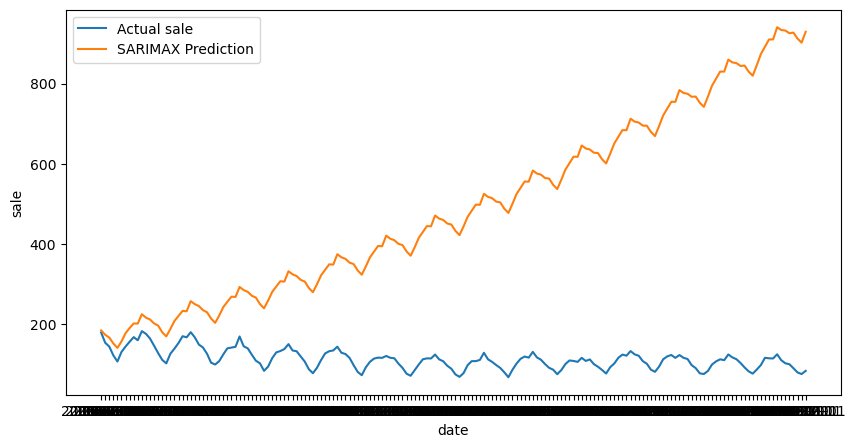

In [80]:
#Future Forecast using SARIMAX
future_dates = pd.DataFrame(pd.date_range(start = '2005-01-01',end = '2020-12-01',freq='MS'),columns=['date'])
future_dates.set_index('date',inplace=True)

future_forecast = model_sarimax_fit.predict(start=future_dates.index[0],end=future_dates.index[-1])
print(future_forecast)

#Plot Future Forecast
plt.figure(figsize=(10,5))
sns.lineplot(x=saleD.index,y=saleD['sale'],label = 'Actual sale')
sns.lineplot(x=saleD.index,y=saleD['sarimaxPred'],label='SARIMAX Prediction')
future_forecast.plot(color='black',label='Future Forecast')
plt.title('SARIMAX Model with future Forecast')
plt.legend()
plt.show()

In [81]:
print("Values for Arima")
#Arima
print(mean_absolute_error(saleD['sale'],saleD['arimaPred']))
print(mean_squared_error(saleD['sale'],saleD['arimaPred']))
print(r2_score(saleD['sale'],saleD['arimaPred']))

print("Values for Sarimax")
#Sarima
print(mean_absolute_error(saleD['sale'],saleD['sarimaxPred']))
print(mean_squared_error(saleD['sale'],saleD['sarimaxPred']))
print(r2_score(saleD['sale'],saleD['sarimaxPred']))

Values for Arima
99.17138043841481
11157.470688567399
-17.20069482357275
Values for Sarimax
378.5192433284875
201272.30654680802
-327.32672656255914
